<a href="https://colab.research.google.com/github/Sandesh-Ghimire/Credit-Card-Default/blob/main/optimizedcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

!pip install lime shap

import shap
from lime.lime_tabular import LimeTabularExplainer

import joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=62b0069a2d31346a747330e0430c838e3bb618ad8404a5f349238ec35d3ed78e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [4]:
#2. LOAD DATA
# ================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/default of credit card clients.xls', header=1)

df.rename(columns={"default payment next month": "default"}, inplace=True)
df.drop(columns=["ID"], inplace=True)

print(df.head())


Mounted at /content/drive
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default  

In [5]:
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (for LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [18691  5309]
After SMOTE: [18691 18691]


In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# 6. XGBOOST + HYPERPARAMETER TUNING
# ================================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [9]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [10]:
# 8. THRESHOLD TUNING
# ================================
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))

# FINAL THRESHOLD (SELECTED)
y_pred = (y_prob > 0.4).astype(int)



Threshold: 0.2
              precision    recall  f1-score   support

           0       0.91      0.39      0.54      4673
           1       0.29      0.86      0.43      1327

    accuracy                           0.49      6000
   macro avg       0.60      0.63      0.49      6000
weighted avg       0.77      0.49      0.52      6000


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.60      0.72      4673
           1       0.34      0.74      0.47      1327

    accuracy                           0.63      6000
   macro avg       0.62      0.67      0.59      6000
weighted avg       0.77      0.63      0.66      6000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.88      0.74      0.80      4673
           1       0.41      0.64      0.50      1327

    accuracy                           0.72      6000
   macro avg       0.64      0.69      0.65      6000
weighted avg       0.77   

In [11]:
# 9. MODEL EVALUATION
# ================================
print("\nFinal XGBoost Model")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))



Final XGBoost Model
Accuracy: 0.7161666666666666
ROC-AUC: 0.7489651384414079
              precision    recall  f1-score   support

           0       0.88      0.74      0.80      4673
           1       0.41      0.64      0.50      1327

    accuracy                           0.72      6000
   macro avg       0.64      0.69      0.65      6000
weighted avg       0.77      0.72      0.74      6000



In [12]:
# 10. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3447 1226]
 [ 477  850]]


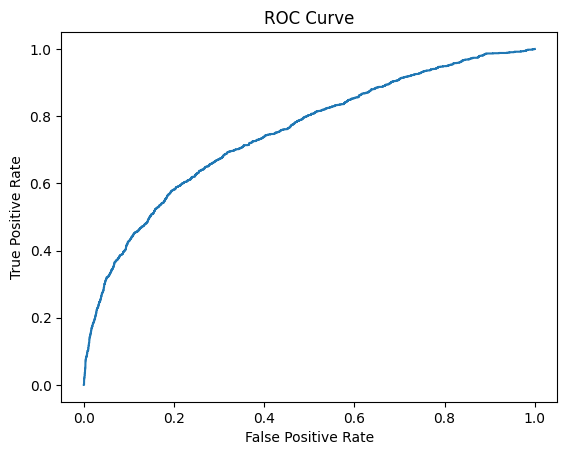

In [13]:
# 11. ROC CURVE
# ================================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


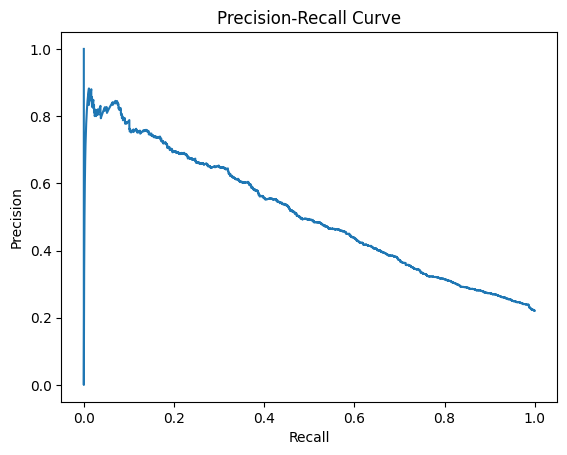

In [14]:
# 12. PRECISION-RECALL CURVE
# ================================
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

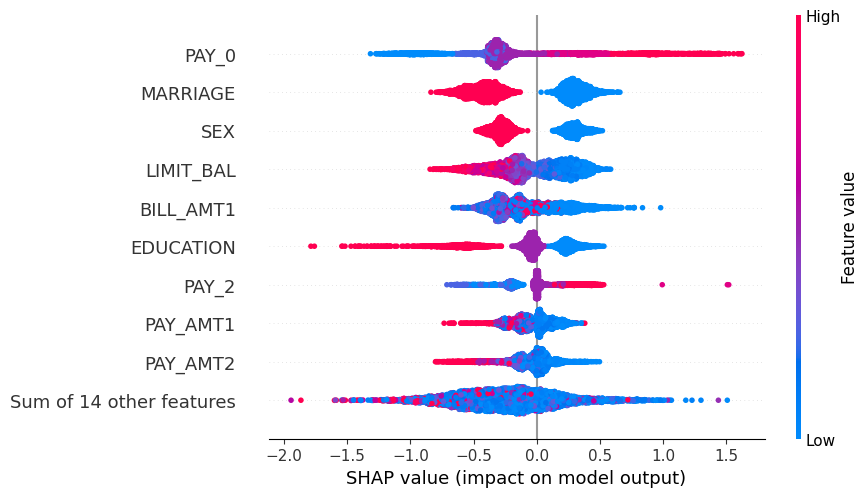

In [15]:
# 13. SHAP (GLOBAL EXPLAINABILITY)
# ================================
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)


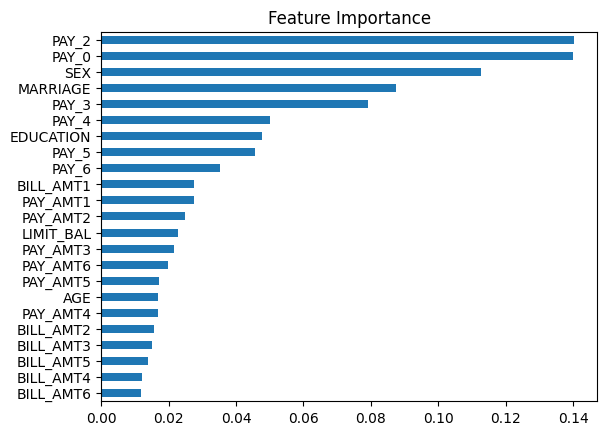

In [16]:
# 14. FEATURE IMPORTANCE
# ================================
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


In [17]:
# 15. LIME (LOCAL EXPLAINABILITY)
# ================================
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    best_model.predict_proba
)

exp.show_in_notebook()


In [18]:
# 16. FAIRNESS ANALYSIS
# ================================
df_fair = X_test.copy()
df_fair["prediction"] = y_pred

male_rate = df_fair[df_fair["SEX"] == 1]["prediction"].mean()
female_rate = df_fair[df_fair["SEX"] == 2]["prediction"].mean()

print("Male Default Rate:", male_rate)
print("Female Default Rate:", female_rate)
print("Demographic Parity Difference:", abs(male_rate - female_rate))


Male Default Rate: 0.47293921731890093
Female Default Rate: 0.2612562534741523
Demographic Parity Difference: 0.2116829638447486


In [19]:
# 17. DSS (RISK CLASSIFICATION)
# ================================
def risk_level(p):
    if p < 0.25:
        return "Low Risk"
    elif p < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

risk = [risk_level(p) for p in y_prob]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob,
    "Risk Level": risk
})

print(results.head())


   Actual  Probability   Risk Level
0       0     0.306029  Medium Risk
1       0     0.467620  Medium Risk
2       0     0.457138  Medium Risk
3       1     0.178344     Low Risk
4       0     0.034073     Low Risk


In [20]:
# 18. SAVE MODEL
# ================================
joblib.dump(best_model, "model.pkl")

['model.pkl']